# 04 - DNN Training

**Architecture**: Dense(256) -> Dense(128) -> Dense(64) -> Dense(1)
**Framework**: TensorFlow / Keras
**GPU**: T4 x2 (Kaggle)

## Model architecture
Input (N features)
    -> Dense(256, relu) + BatchNorm + Dropout(0.3)
    -> Dense(128, relu) + BatchNorm + Dropout(0.3)
    -> Dense(64, relu)
    -> Dense(1, sigmoid)

In [197]:
# Imports
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
 )
from sklearn.utils.class_weight import compute_class_weight

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'{len(gpus)} GPU(s) configured')
else:
    print('No GPU - training on CPU')

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
2 GPU(s) configured


In [198]:
# Load data with Spark, then convert to pandas
spark = (
    SparkSession.builder
    .appName('DNN_Training')
    .master('local[*]')
    .config('spark.driver.memory', '8g')
    .getOrCreate()
 )

df_spark = spark.read.parquet(os.path.join(OUTPUT_DIR, 'brfss_featured.parquet'))

feature_path = os.path.join(OUTPUT_DIR, 'feature_selection_results.json')
if os.path.exists(feature_path):
    with open(feature_path, 'r') as f:
        feature_info = json.load(f)
    feature_cols = feature_info.get('final_features', [])
else:
    feature_cols = [c for c in df_spark.columns if c != 'HeartDiseaseorAttack']

TARGET_COL = 'HeartDiseaseorAttack'
if TARGET_COL not in df_spark.columns:
    raise ValueError(f'Missing target column: {TARGET_COL}')

# Ensure derived features exist if requested
if 'RiskScore' in feature_cols and 'RiskScore' not in df_spark.columns:
    risk_components = [c for c in ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'Stroke', 'DiffWalk', 'HvyAlcoholConsump'] if c in df_spark.columns]
    if risk_components:
        risk_expr = None
        for c in risk_components:
            risk_expr = F.col(c) if risk_expr is None else (risk_expr + F.col(c))
        df_spark = df_spark.withColumn('RiskScore', risk_expr)

if 'HealthIndex' in feature_cols and 'HealthIndex' not in df_spark.columns:
    if all(c in df_spark.columns for c in ['GenHlth', 'MentHlth', 'PhysHlth']):
        df_spark = df_spark.withColumn(
            'HealthIndex',
            F.col('GenHlth') + (F.col('MentHlth') / 6.0) + (F.col('PhysHlth') / 6.0)
        )

# Keep available features only
available = [c for c in feature_cols if c in df_spark.columns and c != TARGET_COL]
missing = [c for c in feature_cols if c not in df_spark.columns]
if missing:
    print(f'Missing features dropped: {missing}')

if not available:
    raise ValueError('No features available for training.')

df = df_spark.select(available + [TARGET_COL]).dropna().toPandas()
print(f'Dataframe shape: {df.shape}')

X = df[available].values
y = df[TARGET_COL].astype(int).values
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Unique target values: {np.unique(y)}')
print(f'Class distribution: {np.bincount(y)}')
print(f'Positive rate: {y.mean() * 100:.2f}%')

spark.stop()
print('Spark stopped - switching to pandas/tensorflow')

Dataframe shape: (1760241, 16)
X shape: (1760241, 15), y shape: (1760241,)
Unique target values: [0 1]
Class distribution: [1578647  181594]
Positive rate: 10.32%
Spark stopped - switching to pandas/tensorflow


In [199]:
# Train/validation/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176,
    random_state=SEED, stratify=y_train_full
)

print(f'Train: {X_train.shape[0]:,} ({y_train.mean() * 100:.1f}% positive)')
print(f'Val  : {X_val.shape[0]:,} ({y_val.mean() * 100:.1f}% positive)')
print(f'Test : {X_test.shape[0]:,} ({y_test.mean() * 100:.1f}% positive)')

Train: 1,232,872 (10.3% positive)
Val  : 263,332 (10.3% positive)
Test : 264,037 (10.3% positive)


In [200]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Features normalized (StandardScaler)')

Features normalized (StandardScaler)


In [201]:
# Handle class imbalance
USE_SMOTE = False

if USE_SMOTE:
    try:
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(random_state=SEED)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        class_weight_dict = None
        print('SMOTE applied to training set')
        print(f'Train distribution after SMOTE: {np.bincount(y_train)}')
    except ImportError:
        raise ImportError('imblearn is not installed. Disable SMOTE or install imbalanced-learn.')
else:
    class_weights_values = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights_values)}
    print(f'Class weights: {class_weight_dict}')

Class weights: {0: 0.5575160330763881, 1: 4.8466140939861155}


## DNN architecture
- Input -> Dense(256, ReLU) + BatchNorm + Dropout(0.3)
- Dense(128, ReLU) + BatchNorm + Dropout(0.3)
- Dense(64, ReLU)
- Dense(1, Sigmoid)

Optimizer: Adam (lr=1e-3)
Loss: Binary Crossentropy

In [202]:
def build_dnn_model(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_dnn_model(X_train.shape[1])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,081 (180.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [203]:
# Training callbacks
my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, 'dnn_best_model.h5'),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print('Callbacks configured')

Callbacks configured


In [204]:
# Train the model
print('Training started...')
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=my_callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f'Training completed in {training_time:.1f}s ({training_time / 60:.1f} min)')
print(f"Epochs run: {len(history.history['loss'])}")

Training started...
Epoch 1/50
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6662 - auc: 0.7881 - loss: 0.5806 - precision: 0.2091 - recall: 0.7897
Epoch 1: val_auc improved from None to 0.81750, saving model to /kaggle/working/dnn_best_model.h5



Epoch 1: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.6867 - auc: 0.8054 - loss: 0.5527 - precision: 0.2195 - recall: 0.7970 - val_accuracy: 0.6959 - val_auc: 0.8175 - val_loss: 0.5339 - val_precision: 0.2262 - val_recall: 0.8049 - learning_rate: 0.0010
Epoch 2/50
1197/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6955 - auc: 0.8151 - loss: 0.5350 - precision: 0.2249 - recall: 0.8010
Epoch 2: val_auc improved from 0.81750 to 0.81895, saving model to /kaggle/working/dnn_best_model.h5



Epoch 2: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6952 - auc: 0.8158 - loss: 0.5332 - precision: 0.2256 - recall: 0.8036 - val_accuracy: 0.6928 - val_auc: 0.8189 - val_loss: 0.5321 - val_precision: 0.2254 - val_recall: 0.8117 - learning_rate: 0.0010
Epoch 3/50
1202/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6979 - auc: 0.8165 - loss: 0.5278 - precision: 0.2265 - recall: 0.8021
Epoch 3: val_auc improved from 0.81895 to 0.81901, saving model to /kaggle/working/dnn_best_model.h5



Epoch 3: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6967 - auc: 0.8168 - loss: 0.5269 - precision: 0.2267 - recall: 0.8045 - val_accuracy: 0.6871 - val_auc: 0.8190 - val_loss: 0.5363 - val_precision: 0.2231 - val_recall: 0.8187 - learning_rate: 0.0010
Epoch 4/50
1197/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6968 - auc: 0.8170 - loss: 0.5242 - precision: 0.2260 - recall: 0.8036
Epoch 4: val_auc improved from 0.81901 to 0.81911, saving model to /kaggle/working/dnn_best_model.h5



Epoch 4: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6963 - auc: 0.8172 - loss: 0.5239 - precision: 0.2265 - recall: 0.8048 - val_accuracy: 0.6927 - val_auc: 0.8191 - val_loss: 0.5350 - val_precision: 0.2255 - val_recall: 0.8126 - learning_rate: 0.0010
Epoch 5/50
1194/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6983 - auc: 0.8173 - loss: 0.5226 - precision: 0.2266 - recall: 0.8013
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auc improved from 0.81911 to 0.81921, saving model to /kaggle/working/dnn_best_model.h5


...


Epoch 22: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6977 - auc: 0.8205 - loss: 0.5164 - precision: 0.2280 - recall: 0.8085 - val_accuracy: 0.7002 - val_auc: 0.8205 - val_loss: 0.5226 - val_precision: 0.2290 - val_recall: 0.8055 - learning_rate: 1.2500e-04
Epoch 23/50
1189/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6989 - auc: 0.8204 - loss: 0.5161 - precision: 0.2277 - recall: 0.8057
Epoch 23: val_auc did not improve from 0.82051
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6978 - auc: 0.8206 - loss: 0.5163 - precision: 0.2279 - recall: 0.8076 - val_accuracy: 0.6994 - val_auc: 0.8205 - val_loss: 0.5239 - val_precision: 0.2288 - val_recall: 0.8071 - learning_rate: 1.2500e-04
Epoch 24/50
1194/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6993 - auc: 0.8202 - loss: 0.5163 - precision: 0.2279 - recall: 0.8058
Epoch 24: val_auc improved from 0.82051 to 0.82051, saving model to /kaggle/worki


Epoch 24: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6981 - auc: 0.8205 - loss: 0.5163 - precision: 0.2281 - recall: 0.8083 - val_accuracy: 0.6999 - val_auc: 0.8205 - val_loss: 0.5224 - val_precision: 0.2290 - val_recall: 0.8069 - learning_rate: 1.2500e-04
Epoch 25/50
1196/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6983 - auc: 0.8204 - loss: 0.5160 - precision: 0.2275 - recall: 0.8070
Epoch 25: val_auc did not improve from 0.82051
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6973 - auc: 0.8206 - loss: 0.5162 - precision: 0.2278 - recall: 0.8093 - val_accuracy: 0.6977 - val_auc: 0.8205 - val_loss: 0.5249 - val_precision: 0.2280 - val_recall: 0.8088 - learning_rate: 1.2500e-04
Epoch 26/50
1189/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - auc: 0.8203 - loss: 0.5161 - precision: 0.2278 - recall: 0.8061
Epoch 26: val_auc did not improve from 0.82051
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 


Epoch 28: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6979 - auc: 0.8209 - loss: 0.5157 - precision: 0.2282 - recall: 0.8094 - val_accuracy: 0.7005 - val_auc: 0.8205 - val_loss: 0.5200 - val_precision: 0.2294 - val_recall: 0.8064 - learning_rate: 6.2500e-05
Epoch 29/50
1193/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - auc: 0.8207 - loss: 0.5156 - precision: 0.2280 - recall: 0.8072
Epoch 29: val_auc improved from 0.82053 to 0.82053, saving model to /kaggle/working/dnn_best_model.h5



Epoch 29: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6979 - auc: 0.8210 - loss: 0.5156 - precision: 0.2282 - recall: 0.8096 - val_accuracy: 0.7010 - val_auc: 0.8205 - val_loss: 0.5191 - val_precision: 0.2294 - val_recall: 0.8046 - learning_rate: 6.2500e-05
Epoch 30/50
1190/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6989 - auc: 0.8206 - loss: 0.5155 - precision: 0.2278 - recall: 0.8066
Epoch 30: val_auc did not improve from 0.82053
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6978 - auc: 0.8210 - loss: 0.5155 - precision: 0.2281 - recall: 0.8090 - val_accuracy: 0.6994 - val_auc: 0.8205 - val_loss: 0.5207 - val_precision: 0.2288 - val_recall: 0.8071 - learning_rate: 6.2500e-05
Epoch 31/50
1198/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6987 - auc: 0.8206 - loss: 0.5156 - precision: 0.2278 - recall: 0.8075
Epoch 31: val_auc improved from 0.82053 to 0.82055, saving model to /kaggle/worki


Epoch 31: finished saving model to /kaggle/working/dnn_best_model.h5
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6975 - auc: 0.8209 - loss: 0.5155 - precision: 0.2280 - recall: 0.8096 - val_accuracy: 0.6995 - val_auc: 0.8205 - val_loss: 0.5208 - val_precision: 0.2289 - val_recall: 0.8074 - learning_rate: 6.2500e-05
Epoch 32/50
1197/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - auc: 0.8206 - loss: 0.5156 - precision: 0.2279 - recall: 0.8068
Epoch 32: val_auc did not improve from 0.82055
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6981 - auc: 0.8209 - loss: 0.5156 - precision: 0.2283 - recall: 0.8091 - val_accuracy: 0.7009 - val_auc: 0.8205 - val_loss: 0.5185 - val_precision: 0.2295 - val_recall: 0.8052 - learning_rate: 6.2500e-05
Epoch 33/50
1193/1204 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6989 - auc: 0.8207 - loss: 0.5155 - precision: 0.2278 - recall: 0.8065
Epoch 33: val_auc did not improve from 0.82055
1204/1204 ━━━━━━━━━━━━━━━━━━━━ 5s 

In [ ]:
# Learning curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[1, 0].set_title('AUC-ROC', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

# FIXED (N-04-A): Keras 3.x stores LR as 'learning_rate', Keras 2.x used 'lr'
_lr_key = 'learning_rate' if 'learning_rate' in history.history else 'lr'
if _lr_key in history.history:
    axes[1, 1].plot(history.history[_lr_key], linewidth=2, color='purple',
                    marker='.', markersize=4)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'LR not tracked', ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')

plt.suptitle('DNN learning curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dnn_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [206]:
# Predictions on test set
print('Evaluating on test set...')
start_inference = time.time()

y_pred_proba = model.predict(X_test, batch_size=2048).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

inference_time = time.time() - start_inference
print(f'Inference time: {inference_time:.3f}s for {len(X_test):,} samples')

Evaluating on test set...
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Inference time: 0.927s for 264,037 samples


In [207]:
# Classification report
print('=' * 60)
print('CLASSIFICATION REPORT - DNN')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['No CVD (0)', 'CVD (1)']))

CLASSIFICATION REPORT - DNN
              precision    recall  f1-score   support

  No CVD (0)       0.97      0.69      0.80    236798
     CVD (1)       0.23      0.80      0.35     27239

    accuracy                           0.70    264037
   macro avg       0.60      0.74      0.58    264037
weighted avg       0.89      0.70      0.76    264037



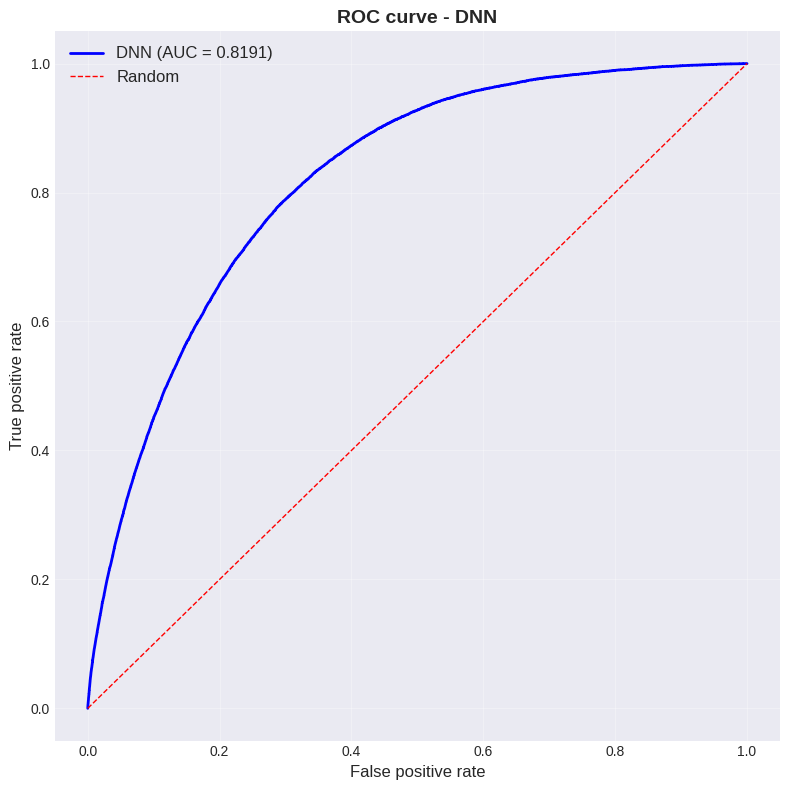

AUC-ROC = 0.8191


In [208]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'DNN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random')
plt.xlabel('False positive rate', fontsize=12)
plt.ylabel('True positive rate', fontsize=12)
plt.title('ROC curve - DNN', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dnn_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC = {auc_score:.4f}')

Seuil par defaut  (0.50)  : precision=0.227  recall=0.802  F1=0.354
Seuil optimal F1  (0.67) : precision=0.305  recall=0.563  F1=0.396
Seuil Youden J    (0.52) : precision=0.234  recall=0.786  F1=0.360


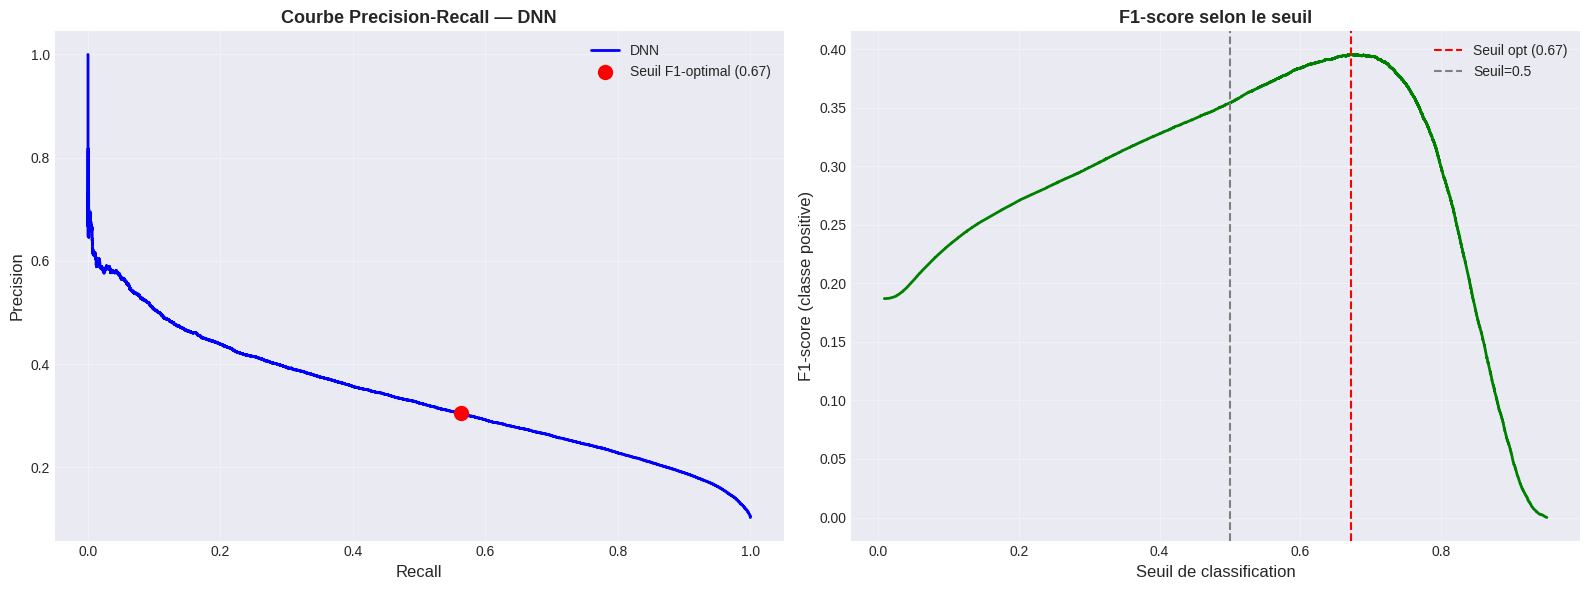


Classification report avec seuil optimal (0.67) :
              precision    recall  f1-score   support

  No CVD (0)       0.94      0.85      0.90    236798
     CVD (1)       0.30      0.56      0.40     27239

    accuracy                           0.82    264037
   macro avg       0.62      0.71      0.65    264037
weighted avg       0.88      0.82      0.84    264037



In [209]:
# Optimisation du seuil de classification
# Avec class_weight eleve (~4.85x), le seuil par defaut 0.5 cree
# beaucoup de faux positifs. On cherche le seuil qui maximise le F1-score.

from sklearn.metrics import precision_recall_curve

# Courbe Precision-Recall
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
f1_per_thresh = 2 * precisions_pr * recalls_pr / (precisions_pr + recalls_pr + 1e-8)

# Seuil optimal par F1 (meilleur compromis precision/recall)
best_f1_idx = np.argmax(f1_per_thresh[:-1])
best_f1_thresh = float(thresholds_pr[best_f1_idx])

# Seuil Youden J (maximise TPR - FPR sur la ROC)
youden_j = tpr - fpr
best_youden_idx = np.argmax(youden_j)
best_youden_thresh = float(thresholds[best_youden_idx])

print(f"Seuil par defaut  (0.50)  : precision={precision_score(y_test,(y_pred_proba>=0.50).astype(int)):.3f}  recall={recall_score(y_test,(y_pred_proba>=0.50).astype(int)):.3f}  F1={f1_score(y_test,(y_pred_proba>=0.50).astype(int)):.3f}")
print(f"Seuil optimal F1  ({best_f1_thresh:.2f}) : precision={precision_score(y_test,(y_pred_proba>=best_f1_thresh).astype(int)):.3f}  recall={recall_score(y_test,(y_pred_proba>=best_f1_thresh).astype(int)):.3f}  F1={f1_score(y_test,(y_pred_proba>=best_f1_thresh).astype(int)):.3f}")
print(f"Seuil Youden J    ({best_youden_thresh:.2f}) : precision={precision_score(y_test,(y_pred_proba>=best_youden_thresh).astype(int)):.3f}  recall={recall_score(y_test,(y_pred_proba>=best_youden_thresh).astype(int)):.3f}  F1={f1_score(y_test,(y_pred_proba>=best_youden_thresh).astype(int)):.3f}")

# Courbe PR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision-Recall curve
axes[0].plot(recalls_pr, precisions_pr, 'b-', linewidth=2, label='DNN')
axes[0].scatter(recalls_pr[best_f1_idx], precisions_pr[best_f1_idx],
                color='red', s=100, zorder=5, label=f'Seuil F1-optimal ({best_f1_thresh:.2f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Courbe Precision-Recall — DNN', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds_pr, f1_per_thresh[:-1], 'g-', linewidth=2)
axes[1].axvline(x=best_f1_thresh, color='red', linestyle='--', label=f'Seuil opt ({best_f1_thresh:.2f})')
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Seuil=0.5')
axes[1].set_xlabel('Seuil de classification', fontsize=12)
axes[1].set_ylabel('F1-score (classe positive)', fontsize=12)
axes[1].set_title('F1-score selon le seuil', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dnn_threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Utiliser le seuil optimal pour les metriques finales
BEST_THRESHOLD = best_f1_thresh
y_pred_opt = (y_pred_proba >= BEST_THRESHOLD).astype(int)
print(f"\nClassification report avec seuil optimal ({BEST_THRESHOLD:.2f}) :")
print(classification_report(y_test, y_pred_opt, target_names=['No CVD (0)', 'CVD (1)']))

In [ ]:
# FIXED (N-04-B): confusion matrix at the optimal threshold to match dnn_metrics.json
# (original code used y_pred at threshold 0.5, inconsistent with the stored JSON matrix)
_cm_threshold = BEST_THRESHOLD if 'BEST_THRESHOLD' in globals() else 0.5
_y_pred_for_cm = (y_pred_proba >= _cm_threshold).astype(int)
cm = confusion_matrix(y_test, _y_pred_for_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['No CVD (0)', 'CVD (1)'],
            yticklabels=['No CVD (0)', 'CVD (1)'])
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion matrix - DNN (threshold={_cm_threshold:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dnn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [211]:
# Sauvegarder le modele et les metriques

# Format .keras (natif Keras 3) — evite le warning HDF5 legacy
model.save(os.path.join(OUTPUT_DIR, 'dnn_model.keras'))
# Garder aussi .h5 pour compatibilite Phase 5
model.save(os.path.join(OUTPUT_DIR, 'dnn_model.h5'))
print('Saved dnn_model.keras + dnn_model.h5')

history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'dnn_training_history.csv'), index=False)
print('Saved dnn_training_history.csv')

# Metriques avec seuil par defaut ET seuil optimal
BEST_THRESHOLD = BEST_THRESHOLD if 'BEST_THRESHOLD' in globals() else 0.5
y_pred_opt = (y_pred_proba >= BEST_THRESHOLD).astype(int)

dnn_metrics = {
    'model': 'DNN',
    'architecture': '256-128-64-1',
    'epochs_trained': len(history.history['loss']),
    'best_epoch': int(np.argmax(history.history['val_auc'])) + 1,
    'best_val_auc': float(max(history.history['val_auc'])),
    'training_time_seconds': round(training_time, 2),
    'inference_time_seconds': round(inference_time, 4),
    'batch_size': 1024,
    'optimizer': 'Adam',
    'initial_lr': 1e-3,
    'n_features': X_train.shape[1],
    'n_train': int(X_train.shape[0]),
    'positive_rate_train': float(y_train.mean()),
    # Metriques seuil 0.5 (standard)
    'metrics_threshold_05': {
        'threshold': 0.5,
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred)),
        'recall': float(recall_score(y_test, y_pred)),
        'f1_score': float(f1_score(y_test, y_pred)),
        'auc_roc': float(auc_score)
    },
    # Metriques seuil optimal F1
    'metrics_optimal_threshold': {
        'threshold': round(BEST_THRESHOLD, 4),
        'accuracy': float(accuracy_score(y_test, y_pred_opt)),
        'precision': float(precision_score(y_test, y_pred_opt)),
        'recall': float(recall_score(y_test, y_pred_opt)),
        'f1_score': float(f1_score(y_test, y_pred_opt)),
        'auc_roc': float(auc_score)
    },
    # Pour retrocompatibilite Phase 5
    'metrics': {
        'accuracy': float(accuracy_score(y_test, y_pred_opt)),
        'precision': float(precision_score(y_test, y_pred_opt)),
        'recall': float(recall_score(y_test, y_pred_opt)),
        'f1_score': float(f1_score(y_test, y_pred_opt)),
        'auc_roc': float(auc_score)
    },
    'optimal_threshold': round(BEST_THRESHOLD, 4),
    'confusion_matrix': confusion_matrix(y_test, y_pred_opt).tolist(),
    'class_weights': {str(k): float(v) for k, v in (class_weight_dict or {}).items()},
    'roc_curve': {'fpr': fpr.tolist(), 'tpr': tpr.tolist()}
}

with open(os.path.join(OUTPUT_DIR, 'dnn_metrics.json'), 'w') as f:
    json.dump(dnn_metrics, f, indent=2)
print('Saved dnn_metrics.json')

print('\n' + '=' * 60)
print('DNN SUMMARY')
print('=' * 60)
print(f"  Epochs           : {dnn_metrics['epochs_trained']} (best: {dnn_metrics['best_epoch']})")
print(f"  Best val AUC     : {dnn_metrics['best_val_auc']:.4f}")
print(f"\n  --- Seuil 0.50 ---")
for m, v in dnn_metrics['metrics_threshold_05'].items():
    if m != 'threshold':
        print(f"  {m:15s} : {v:.4f}")
print(f"\n  --- Seuil optimal ({BEST_THRESHOLD:.2f}) ---")
for m, v in dnn_metrics['metrics_optimal_threshold'].items():
    if m != 'threshold':
        print(f"  {m:15s} : {v:.4f}")
print(f"\n  training_time    : {training_time:.1f}s")
print(f"  inference_time   : {inference_time:.4f}s")

Saved dnn_model.keras + dnn_model.h5
Saved dnn_training_history.csv
Saved dnn_metrics.json

DNN SUMMARY
  Epochs           : 36 (best: 31)
  Best val AUC     : 0.8205

  --- Seuil 0.50 ---
  accuracy        : 0.6983
  precision       : 0.2273
  recall          : 0.8016
  f1_score        : 0.3541
  auc_roc         : 0.8191

  --- Seuil optimal (0.67) ---
  accuracy        : 0.8225
  precision       : 0.3049
  recall          : 0.5629
  f1_score        : 0.3956
  auc_roc         : 0.8191

  training_time    : 177.8s
  inference_time   : 0.9266s


In [212]:
# Save test data and scaler for later phases
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'), y_test)
np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUTPUT_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(OUTPUT_DIR, 'y_val.npy'), y_val)

import joblib
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.pkl'))

print('Saved test data and scaler')

Saved test data and scaler


## Summary

- Data prepared (split 70/15/15, scaling, class weights)
- DNN built and trained with callbacks
- Evaluation metrics computed (accuracy, precision, recall, F1, AUC)
- Model and artifacts saved

Next: move to notebook 05 for XGBoost and Spark benchmark